In [1]:
import sys, pathlib
project_root = pathlib.Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from backtesting import Backtest

from trader.l2_features import build_bt_df
from trader.l4_signal_model import ConfluenceStrategy
from trader.backtest_harness import run_fold, walk_forward

In [3]:
us30_raw = build_bt_df("^DJI")
gold_raw = build_bt_df("GC=F")

common_start = max(us30_raw.index[0], gold_raw.index[0])
common_end = min(us30_raw.index[-1], gold_raw.index[-1])

us30_bt_df = us30_raw.loc[common_start:common_end]
gold_bt_df = gold_raw.loc[common_start:common_end]

print("Common window:", common_start, "->", common_end)
print("US30 bars:", len(us30_bt_df), " Gold bars:", len(gold_bt_df))

Common window: 2024-02-27 00:00:00-05:00 -> 2026-07-20 12:00:00-04:00
US30 bars: 1372  Gold bars: 3636


In [4]:
print("=== US30 (half-capital) ===")
us30_folds = walk_forward(us30_bt_df, cash=25_000)

print("\n=== Gold (half-capital) ===")
gold_folds = walk_forward(gold_bt_df, cash=25_000)

=== US30 (half-capital) ===
Fold: train [2024-02-27 -> 2025-02-27]  test [2025-02-27 -> 2025-05-27]


c:\Users\milat\Documents\us30-trading-bot\trader\backtest_harness.py:38: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt_train = Backtest(train_slice, strategy_cls, cash=cash, commission=0.0002, margin=1/30)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_gri

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(2.0), 'atr_tp_mult': np.float64(4.0)}  Return=-2.57%  WinRate=50.0%  Trades=2
Fold: train [2024-02-27 -> 2025-05-27]  test [2025-05-27 -> 2025-08-27]


c:\Users\milat\Documents\us30-trading-bot\trader\backtest_harness.py:43: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt_test = Backtest(test_slice, strategy_cls, cash=cash, commission=0.0002, margin=1/30)
c:\Users\milat\Documents\us30-trading-bot\trader\backtest_harness.py:44: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  test_stats = bt_test.run(**params)
c:\Users\milat\Documents\us30-trading-bot\trader\backtest_harness.py:38: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.Fract

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(2.0), 'atr_tp_mult': np.float64(4.0)}  Return=3.44%  WinRate=33.3%  Trades=3
Fold: train [2024-02-27 -> 2025-08-27]  test [2025-08-27 -> 2025-11-27]


...

c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(10), 'atr_sl_mult': np.float64(2.5), 'atr_tp_mult': np.float64(4.0)}  Return=48.08%  WinRate=70.0%  Trades=10
Fold: train [2024-02-27 -> 2026-02-27]  test [2026-02-27 -> 2026-05-27]


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..

  params={'adx_threshold': np.int64(15), 'swing_lookback': np.int64(20), 'atr_sl_mult': np.float64(2.0), 'atr_tp_mult': np.float64(4.0)}  Return=-2.79%  WinRate=37.5%  Trades=8


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1545: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = self.run(**dict(zip(heatmap.index.names, best_params)))


   fold             us30_test_end             gold_test_end   us30_equity  \
0     1 2025-05-27 07:00:00-04:00 2025-05-27 00:00:00-04:00  24357.871452   
1     2 2025-08-27 07:00:00-04:00 2025-08-27 00:00:00-04:00  25194.615432   
2     3 2025-11-27 07:00:00-05:00 2025-11-27 00:00:00-05:00  23826.848788   
3     4 2026-02-27 07:00:00-05:00 2026-02-27 00:00:00-05:00  22416.197543   
4     5 2026-05-27 07:00:00-04:00 2026-05-27 00:00:00-04:00  23266.145309   

    gold_equity  portfolio_equity  
0  29222.511711      53580.383163  
1  25510.525432      50705.140864  
2  42596.199305      66423.048094  
3  63078.048987      85494.246530  
4  61317.100526      84583.245835  


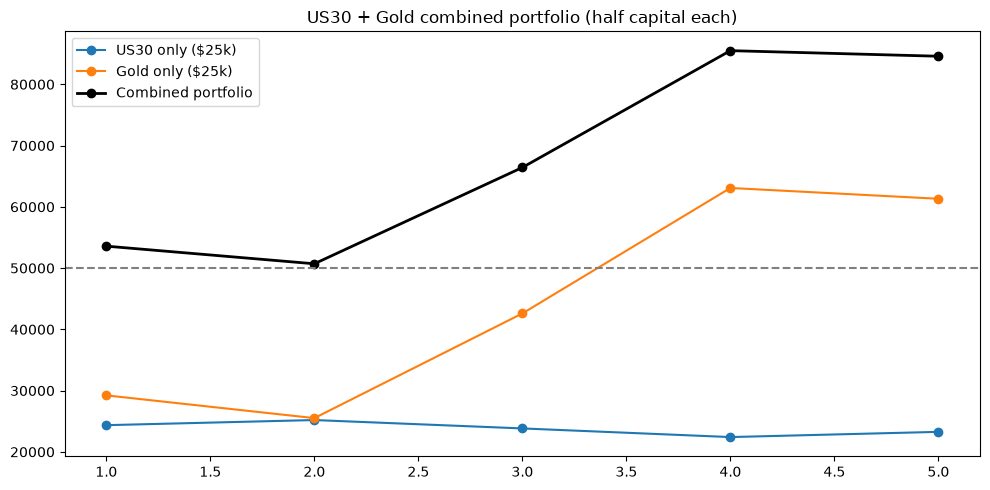

In [5]:
def compound_equity(fold_results, starting_cash=25_000):
    fold_df = pd.DataFrame(fold_results)
    equity = starting_cash
    equities = []
    for r in fold_df["return_pct"]:
        equity *= (1 + r / 100)
        equities.append(equity)
    fold_df["equity_after_fold"] = equities
    return fold_df

us30_df = compound_equity(us30_folds)
gold_df = compound_equity(gold_folds)

n_folds = min(len(us30_df), len(gold_df))
us30_df = us30_df.iloc[:n_folds].reset_index(drop=True)
gold_df = gold_df.iloc[:n_folds].reset_index(drop=True)

portfolio = pd.DataFrame({
    "fold": range(1, n_folds + 1),
    "us30_test_end": us30_df["test_end"],
    "gold_test_end": gold_df["test_end"],
    "us30_equity": us30_df["equity_after_fold"],
    "gold_equity": gold_df["equity_after_fold"],
})
portfolio["portfolio_equity"] = portfolio["us30_equity"] + portfolio["gold_equity"]
print(portfolio)

plt.figure(figsize=(10, 5))
plt.plot(portfolio["fold"], portfolio["us30_equity"], marker="o", label="US30 only ($25k)")
plt.plot(portfolio["fold"], portfolio["gold_equity"], marker="o", label="Gold only ($25k)")
plt.plot(portfolio["fold"], portfolio["portfolio_equity"], marker="o", linewidth=2, color="black", label="Combined portfolio")
plt.axhline(50_000, color="gray", linestyle="--")
plt.title("US30 + Gold combined portfolio (half capital each)")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
fold_params = {'adx_threshold': 15, 'swing_lookback': 20, 'atr_sl_mult': 1.0, 'atr_tp_mult': 2.5}

test3 = us30_bt_df.loc["2025-08-26":"2025-11-26"]
bt3 = Backtest(test3, ConfluenceStrategy, cash=25_000, commission=0.0002, margin=1/30)
stats3 = bt3.run(**fold_params)
print("=== Fold 3 (Aug-Nov 2025) trades ===")
print(stats3._trades[["Size", "EntryTime", "ExitTime", "EntryPrice", "ExitPrice", "PnL", "ReturnPct"]])

test4 = us30_bt_df.loc["2025-11-26":"2026-02-26"]
bt4 = Backtest(test4, ConfluenceStrategy, cash=25_000, commission=0.0002, margin=1/30)
stats4 = bt4.run(**fold_params)
print("\n=== Fold 4 (Nov 2025-Feb 2026) trades ===")
print(stats4._trades[["Size", "EntryTime", "ExitTime", "EntryPrice", "ExitPrice", "PnL", "ReturnPct"]])

=== Fold 3 (Aug-Nov 2025) trades ===
   Size                 EntryTime                  ExitTime    EntryPrice  \
0     1 2025-10-03 12:00:00-04:00 2025-10-03 12:00:00-04:00  47017.679688   
1     1 2025-10-21 12:00:00-04:00 2025-10-22 12:00:00-04:00  47037.839844   
2     1 2025-10-24 12:00:00-04:00 2025-11-04 07:00:00-05:00  47273.640625   

      ExitPrice         PnL  ReturnPct  
0  46749.651344 -286.781809  -0.006099  
1  46673.692815 -382.889335  -0.008140  
2  46936.775681 -355.707028  -0.007524  

=== Fold 4 (Nov 2025-Feb 2026) trades ===
   Size                 EntryTime                  ExitTime    EntryPrice  \
0     1 2025-12-11 11:00:00-05:00 2025-12-16 07:00:00-05:00  48509.898438   
1     1 2025-12-24 11:00:00-05:00 2025-12-29 07:00:00-05:00  48686.500000   
2     1 2026-01-05 11:00:00-05:00 2026-01-08 07:00:00-05:00  49055.621094   

      ExitPrice         PnL  ReturnPct  
0  48243.139005 -286.110040  -0.005898  
1  48473.085693 -232.846224  -0.004783  
2  48822.244174

C:\Users\milat\AppData\Local\Temp\ipykernel_26480\4254695036.py:4: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt3 = Backtest(test3, ConfluenceStrategy, cash=25_000, commission=0.0002, margin=1/30)
C:\Users\milat\AppData\Local\Temp\ipykernel_26480\4254695036.py:5: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats3 = bt3.run(**fold_params)
C:\Users\milat\AppData\Local\Temp\ipykernel_26480\4254695036.py:10: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt4

In [7]:
for sl_mult in [1.0, 1.5, 2.0, 2.5]:
    params = {'adx_threshold': 15, 'swing_lookback': 20, 'atr_sl_mult': sl_mult, 'atr_tp_mult': 2.5}
    bt = Backtest(test3, ConfluenceStrategy, cash=25_000, commission=0.0002, margin=1/30)
    stats = bt.run(**params)
    print(f"Fold3 sl_mult={sl_mult}: Return={stats['Return [%]']:.2f}%  WinRate={stats['Win Rate [%]']:.1f}%  Trades={stats['# Trades']}")

for sl_mult in [1.0, 1.5, 2.0, 2.5]:
    params = {'adx_threshold': 15, 'swing_lookback': 20, 'atr_sl_mult': sl_mult, 'atr_tp_mult': 2.5}
    bt = Backtest(test4, ConfluenceStrategy, cash=25_000, commission=0.0002, margin=1/30)
    stats = bt.run(**params)
    print(f"Fold4 sl_mult={sl_mult}: Return={stats['Return [%]']:.2f}%  WinRate={stats['Win Rate [%]']:.1f}%  Trades={stats['# Trades']}")

C:\Users\milat\AppData\Local\Temp\ipykernel_26480\3681862006.py:3: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(test3, ConfluenceStrategy, cash=25_000, commission=0.0002, margin=1/30)
C:\Users\milat\AppData\Local\Temp\ipykernel_26480\3681862006.py:4: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = bt.run(**params)
C:\Users\milat\AppData\Local\Temp\ipykernel_26480\3681862006.py:3: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtes

Fold3 sl_mult=1.0: Return=-4.32%  WinRate=0.0%  Trades=3
Fold3 sl_mult=1.5: Return=-6.26%  WinRate=0.0%  Trades=3
Fold3 sl_mult=2.0: Return=-4.33%  WinRate=25.0%  Trades=4
Fold3 sl_mult=2.5: Return=-5.79%  WinRate=25.0%  Trades=4
Fold4 sl_mult=1.0: Return=-3.09%  WinRate=0.0%  Trades=3
Fold4 sl_mult=1.5: Return=-0.84%  WinRate=33.3%  Trades=3
Fold4 sl_mult=2.0: Return=-1.80%  WinRate=33.3%  Trades=3
Fold4 sl_mult=2.5: Return=0.27%  WinRate=50.0%  Trades=2


C:\Users\milat\AppData\Local\Temp\ipykernel_26480\3681862006.py:9: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(test4, ConfluenceStrategy, cash=25_000, commission=0.0002, margin=1/30)
C:\Users\milat\AppData\Local\Temp\ipykernel_26480\3681862006.py:9: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(test4, ConfluenceStrategy, cash=25_000, commission=0.0002, margin=1/30)
C:\Users\milat\AppData\Local\Temp\ipykernel_26480\3681862006.py:9: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not 

In [8]:
us30_bt_df

Price,Open,High,Low,Close,Volume,ma_360,ma_200,ma_89,ema_21,ema_8,macd,macd_signal,macd_hist,atr_14,plus_di,minus_di,adx_14
time,,,,,,,,,,,,,,,,,
2024-02-27 07:00:00-05:00,39087.898438,39087.898438,38902.488281,38910.628906,27645292,NaN,37435.708066,38332.616441,38873.645933,39017.413449,142.674797,131.936134,10.738663,167.853663,27.876561,24.458164,19.118614
2024-02-27 11:00:00-05:00,38910.808594,38982.339844,38881.898438,38975.601562,110728184,NaN,37455.725215,38348.177800,38882.914627,39008.121918,132.413756,132.031658,0.382098,163.038502,26.649874,24.283960,18.084790
2024-02-27 15:00:00-05:00,38975.179688,38994.960938,38939.738281,38973.531250,40759518,NaN,37475.848516,38365.688509,38891.152502,39000.435103,122.700337,130.165394,-7.465057,155.337370,26.553509,23.667318,17.203519
2024-02-28 07:00:00-05:00,38938.078125,38941.699219,38741.679688,38899.460938,31008019,NaN,37495.160312,38383.901554,38891.907814,38977.996400,107.783071,125.688929,-17.905858,160.802669,23.818803,30.027623,16.798311
2024-02-28 11:00:00-05:00,38901.738281,38938.921875,38822.589844,38928.359375,100692116,NaN,37513.702910,38401.618636,38895.221592,38966.965950,97.172746,119.985693,-22.812946,157.626195,22.563170,28.444685,16.422046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-16 12:00:00-04:00,52611.480469,52728.878906,52367.421875,52553.078125,220100546,49271.147049,49480.712500,51358.679117,52476.693899,52549.799730,120.436953,159.541057,-39.104104,366.322316,20.231518,20.735569,15.274129
2026-07-17 08:00:00-04:00,52426.460938,52610.968750,51986.738281,52410.941406,104449161,49284.100141,49495.243652,51388.348358,52470.716400,52518.942325,101.252746,147.883395,-46.630649,384.744327,17.886894,25.400000,15.422873
2026-07-17 12:00:00-04:00,52410.730469,52419.000000,52120.718750,52158.960938,185019456,49295.995757,49508.549512,51416.836245,52442.374994,52438.946461,64.967501,131.300216,-66.332715,378.568393,16.880221,23.970489,15.560991


In [9]:
#us30_bt_df.iloc[-30:]#